# Smart Parking Slot Detection (YOLOv8)

End-to-end pipeline for the **Parking Space Detection** dataset in this folder.

**Dataset layout:**
```
Smart parking/
├── images/           # 0.png … 32.png
├── boxes/            # segmentation masks (optional)
├── annotations.xml   # CVAT polygons (free / not_free / partial)
└── parking.csv       # image ↔ mask index
```

**Pipeline:** install → explore → parse polygons → YOLO labels → split → train → evaluate → infer → occupancy report → export ONNX

## Step 1 — Install dependencies

In [1]:
%pip install -q ultralytics opencv-python-headless matplotlib seaborn pandas numpy Pillow PyYAML tqdm scikit-learn

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
PyTorch : 2.12.0+cpu
CUDA    : False


## Step 2 — Imports & paths

In [2]:
import platform
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml
import torch
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

DATASET_ROOT = Path(r"C:/Users/nsti-/Desktop/Smart parking").resolve()
IMAGES_DIR   = DATASET_ROOT / "images"
BOXES_DIR    = DATASET_ROOT / "boxes"
ANNOT_XML    = DATASET_ROOT / "annotations.xml"
PARKING_CSV  = DATASET_ROOT / "parking.csv"

OUTPUT_ROOT  = DATASET_ROOT / "smart_parking_yolo"
YOLO_DATASET = OUTPUT_ROOT / "dataset"
RUNS_DIR     = OUTPUT_ROOT / "runs"

for d in [
    YOLO_DATASET / "images" / "train", YOLO_DATASET / "images" / "val",
    YOLO_DATASET / "images" / "test", YOLO_DATASET / "labels" / "train",
    YOLO_DATASET / "labels" / "val", YOLO_DATASET / "labels" / "test",
    RUNS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {
    "free_parking_space": 0,
    "not_free_parking_space": 1,
    "partially_free_parking_space": 2,
}
CLASS_NAMES = ["free", "busy", "partial"]
CLASS_COLORS = {"free": (0, 200, 80), "busy": (50, 50, 220), "partial": (0, 200, 255)}

MODEL_SIZE = "yolov8m"
RUN_NAME   = f"parking_{MODEL_SIZE}"
WORKERS    = 0 if platform.system() == "Windows" else 4
DEVICE     = 0 if torch.cuda.is_available() else "cpu"

print(f"Dataset root : {DATASET_ROOT}")
print(f"Classes      : {CLASS_NAMES}")
print(f"Device       : {DEVICE}")

Dataset root : C:\Users\nsti-\Desktop\Smart parking
Classes      : ['free', 'busy', 'partial']
Device       : cpu


## Step 3 — Explore dataset

In [3]:
image_files = sorted(IMAGES_DIR.glob("*.png")) + sorted(IMAGES_DIR.glob("*.jpg"))
print(f"Images in /images : {len(image_files)}")
print(f"XML exists        : {ANNOT_XML.exists()}")
print(f"CSV exists        : {PARKING_CSV.exists()}")

if PARKING_CSV.exists():
    df_csv = pd.read_csv(PARKING_CSV)
    display(df_csv.head())
    print(f"CSV rows: {len(df_csv)}")

Images in /images : 30
XML exists        : True
CSV exists        : True


,id,image,mask
0,0,images/0.png,boxes/0.png
1,1,images/1.png,boxes/1.png
2,2,images/2.png,boxes/2.png
3,3,images/3.png,boxes/3.png
4,4,images/4.png,boxes/4.png


CSV rows: 33


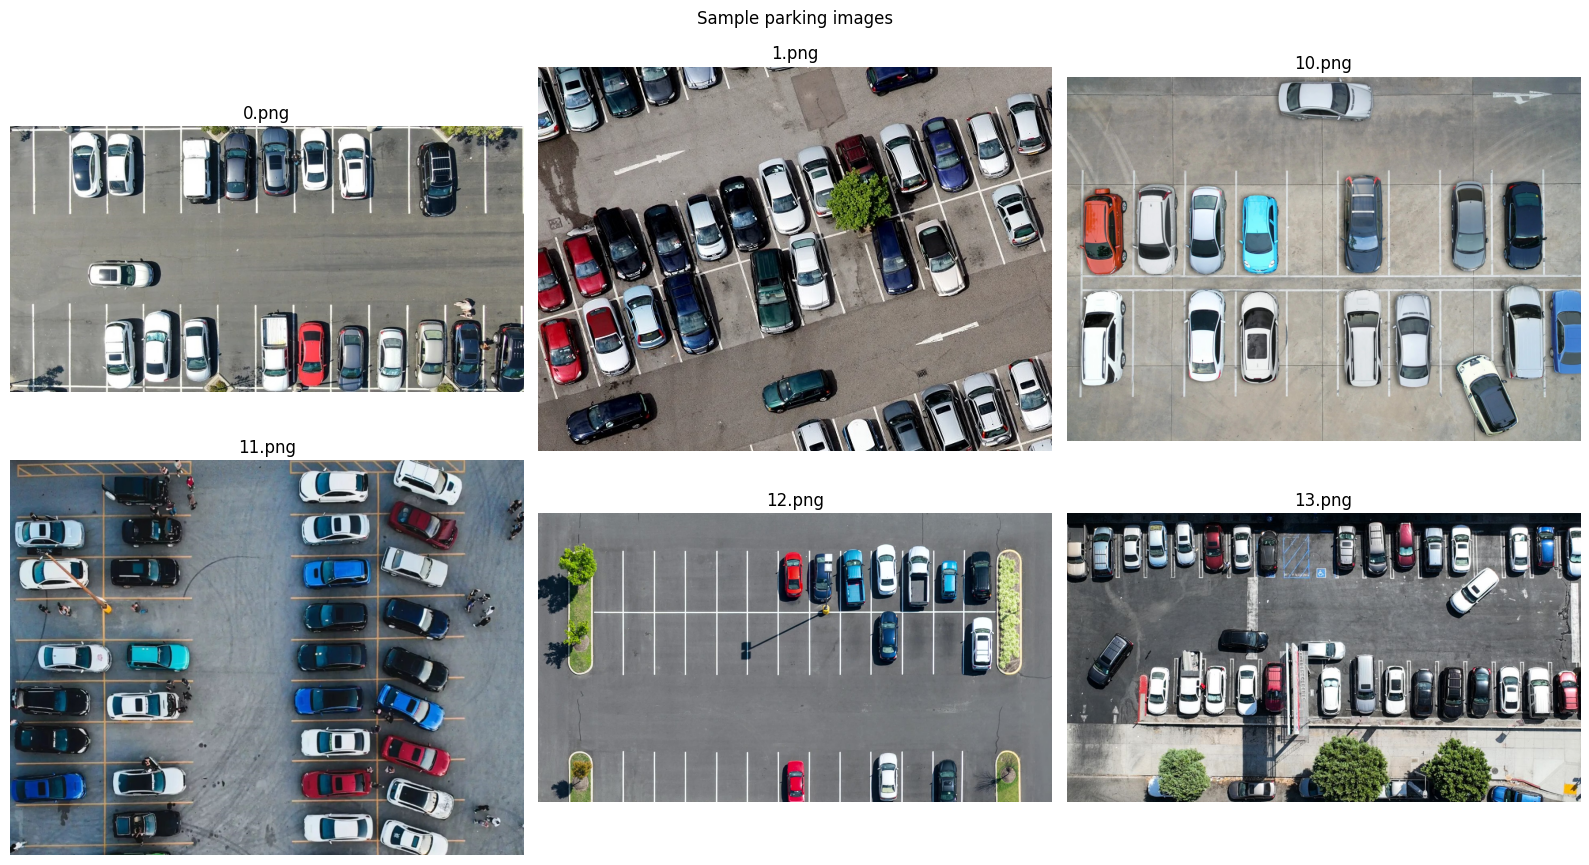

In [4]:
n_show = min(6, len(image_files))
if n_show == 0:
    raise FileNotFoundError(f"No images found in {IMAGES_DIR}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = np.atleast_1d(axes).ravel()
for ax, img_path in zip(axes, image_files[:n_show]):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")
for ax in axes[n_show:]:
    ax.axis("off")
plt.suptitle("Sample parking images")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "sample_images.png", dpi=120, bbox_inches="tight")
plt.show()

## Step 4 — Parse CVAT polygon annotations

In [5]:
def polygon_to_bbox(points_str: str):
    xs, ys = [], []
    for pair in points_str.strip().split(";"):
        if not pair.strip():
            continue
        x, y = pair.split(",")
        xs.append(float(x))
        ys.append(float(y))
    return min(xs), min(ys), max(xs), max(ys)


def parse_cvat_xml(xml_path: Path):
    root = ET.parse(xml_path).getroot()
    data = {}
    for img_el in root.findall("image"):
        name = img_el.get("name", "").strip()
        width = int(img_el.get("width", 0))
        height = int(img_el.get("height", 0))
        boxes = []
        for poly in img_el.findall("polygon"):
            label = poly.get("label", "").strip()
            pts = poly.get("points", "")
            if label in LABEL_MAP and pts:
                boxes.append((label, *polygon_to_bbox(pts)))
        for box_el in img_el.findall("box"):
            label = box_el.get("label", "").strip()
            if label in LABEL_MAP:
                boxes.append((
                    label,
                    float(box_el.get("xtl", 0)),
                    float(box_el.get("ytl", 0)),
                    float(box_el.get("xbr", 0)),
                    float(box_el.get("ybr", 0)),
                ))
        data[name] = {"width": width, "height": height, "boxes": boxes}
    return data


annotations = parse_cvat_xml(ANNOT_XML)
print(f"Annotated images : {len(annotations)}")

counts = {c: 0 for c in CLASS_NAMES}
for meta in annotations.values():
    for label, *_ in meta["boxes"]:
        counts[CLASS_NAMES[LABEL_MAP[label]]] += 1
total_boxes = sum(counts.values())
print(f"Total slots      : {total_boxes}")
for k, v in counts.items():
    pct = 100 * v / total_boxes if total_boxes else 0
    print(f"  {k:8s}: {v:4d} ({pct:.1f}%)")

Annotated images : 30
Total slots      : 903
  free    :  273 (30.2%)
  busy    :  624 (69.1%)
  partial :    6 (0.7%)


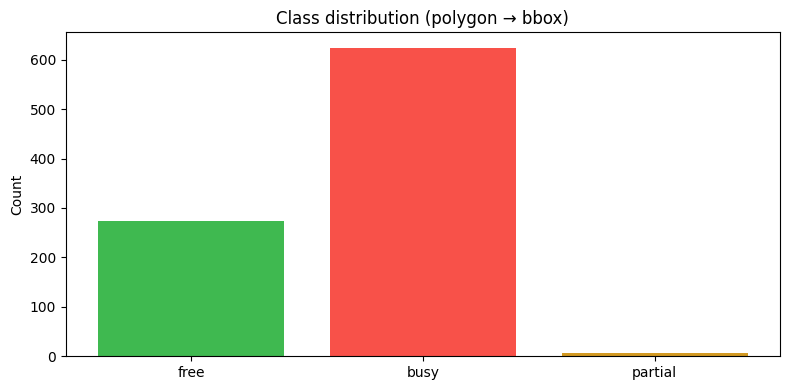

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts.keys(), counts.values(), color=["#3fb950", "#f85149", "#d29922"])
ax.set_title("Class distribution (polygon → bbox)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "class_distribution.png", dpi=120)
plt.show()

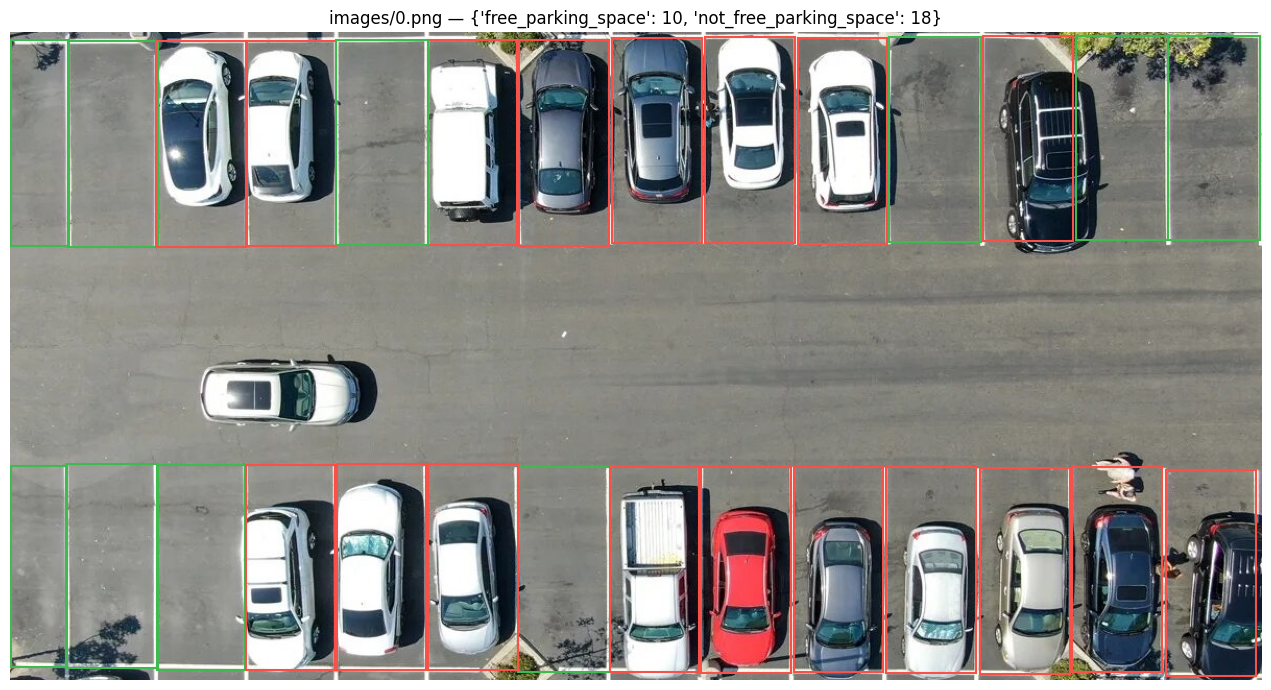

In [7]:
def resolve_image_path(name: str):
    for p in (DATASET_ROOT / name, IMAGES_DIR / Path(name).name):
        if p.exists():
            return p
    return None


def draw_annotations(img_name, annotations):
    img_path = resolve_image_path(img_name)
    if img_path is None:
        raise FileNotFoundError(f"Image not found for {img_name}")
    img_rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img_rgb)
    color_map = {
        "free_parking_space": "#3fb950",
        "not_free_parking_space": "#f85149",
        "partially_free_parking_space": "#d29922",
    }
    tallies = {}
    for label, xtl, ytl, xbr, ybr in annotations[img_name]["boxes"]:
        rect = patches.Rectangle(
            (xtl, ytl), xbr - xtl, ybr - ytl,
            linewidth=1.5, edgecolor=color_map.get(label, "white"), facecolor="none",
        )
        ax.add_patch(rect)
        tallies[label] = tallies.get(label, 0) + 1
    ax.set_title(f"{img_name} — {tallies}")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / f"annotated_{Path(img_name).stem}.png", dpi=120, bbox_inches="tight")
    plt.show()


draw_annotations(next(iter(annotations)), annotations)

## Step 5 — Convert to YOLO format

In [8]:
def to_yolo_line(class_id, xtl, ytl, xbr, ybr, img_w, img_h):
    cx = ((xtl + xbr) / 2) / img_w
    cy = ((ytl + ybr) / 2) / img_h
    w = (xbr - xtl) / img_w
    h = (ybr - ytl) / img_h
    cx, cy, w, h = [max(0.0, min(1.0, v)) for v in (cx, cy, w, h)]
    return f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"


TEMP_IMAGES = OUTPUT_ROOT / "all_images"
TEMP_LABELS = OUTPUT_ROOT / "all_labels"
for p in (TEMP_IMAGES, TEMP_LABELS):
    if p.exists():
        shutil.rmtree(p)
    p.mkdir(parents=True)

converted, skipped = 0, 0
for img_name, meta in tqdm(annotations.items(), desc="YOLO conversion"):
    img_path = resolve_image_path(img_name)
    if img_path is None:
        skipped += 1
        continue
    img_w, img_h = meta["width"], meta["height"]
    if img_w <= 0 or img_h <= 0:
        tmp = cv2.imread(str(img_path))
        if tmp is None:
            skipped += 1
            continue
        img_h, img_w = tmp.shape[:2]
    lines = []
    for label, xtl, ytl, xbr, ybr in meta["boxes"]:
        if xbr <= xtl or ybr <= ytl:
            continue
        lines.append(to_yolo_line(LABEL_MAP[label], xtl, ytl, xbr, ybr, img_w, img_h))
    if not lines:
        skipped += 1
        continue
    shutil.copy(img_path, TEMP_IMAGES / img_path.name)
    (TEMP_LABELS / f"{img_path.stem}.txt").write_text("\n".join(lines))
    converted += 1

print(f"Converted: {converted} | Skipped: {skipped}")
if converted == 0:
    raise RuntimeError("No images converted — check paths and annotations.xml")

YOLO conversion: 100%|██████████| 30/30 [00:00<00:00, 271.37it/s]

Converted: 30 | Skipped: 0


## Step 6 — Train / val / test split (70 / 20 / 10)

In [9]:
all_stems = [p.stem for p in sorted(TEMP_IMAGES.glob("*"))]
train_val, test_stems = train_test_split(all_stems, test_size=0.10, random_state=42)
train_stems, val_stems = train_test_split(train_val, test_size=0.222, random_state=42)
print(f"Train: {len(train_stems)} | Val: {len(val_stems)} | Test: {len(test_stems)}")


def copy_split(stems, split_name):
    img_out = YOLO_DATASET / "images" / split_name
    lbl_out = YOLO_DATASET / "labels" / split_name
    for f in list(img_out.glob("*")) + list(lbl_out.glob("*")):
        f.unlink()
    for stem in stems:
        for ext in (".png", ".jpg", ".jpeg"):
            src_img = TEMP_IMAGES / f"{stem}{ext}"
            if src_img.exists():
                shutil.copy(src_img, img_out / src_img.name)
                break
        src_lbl = TEMP_LABELS / f"{stem}.txt"
        if src_lbl.exists():
            shutil.copy(src_lbl, lbl_out / src_lbl.name)


for split, stems in [("train", train_stems), ("val", val_stems), ("test", test_stems)]:
    copy_split(stems, split)
print("Split complete.")

Train: 21 | Val: 6 | Test: 3
Split complete.


## Step 7 — Create data.yaml

In [10]:
yaml_path = YOLO_DATASET / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump({
        "path": str(YOLO_DATASET.resolve()),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": len(CLASS_NAMES),
        "names": CLASS_NAMES,
    }, f, default_flow_style=False)
print(yaml_path.read_text())

names:
- free
- busy
- partial
nc: 3
path: C:\Users\nsti-\Desktop\Smart parking\smart_parking_yolo\dataset
test: images/test
train: images/train
val: images/val



## Step 8 — Train YOLOv8

In [11]:
model = YOLO(f"{MODEL_SIZE}.pt")
print(f"Loaded {MODEL_SIZE} | device={DEVICE} | workers={WORKERS}")

Loaded yolov8m | device=cpu | workers=0


In [12]:
results = model.train(
    data=str(yaml_path),
    epochs=100,
    patience=40,
    imgsz=640,
    batch=4,
    optimizer="AdamW",
    lr0=1e-3,
    lrf=0.01,
    weight_decay=5e-4,
    warmup_epochs=5,
    cos_lr=True,
    close_mosaic=15,
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=8.0,
    translate=0.12,
    scale=0.6,
    shear=2.0,
    perspective=0.0008,
    flipud=0.1,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.15,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    save_period=25,
    device=DEVICE,
    workers=WORKERS,
    exist_ok=True,
    verbose=True,
)

BEST_WEIGHTS = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
print(f"Best weights: {BEST_WEIGHTS}")

New https://pypi.org/project/ultralytics/8.4.53 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.52  Python-3.13.9 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-12500)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\nsti-\Desktop\Smart parking\smart_parking_yolo\dataset\data.yaml, degrees=8.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m.pt, moment

## Step 9 — Evaluation

In [13]:
best_model = YOLO(str(BEST_WEIGHTS))

val_metrics = best_model.val(
    data=str(yaml_path), split="val", imgsz=640, batch=4,
    conf=0.25, iou=0.5, device=DEVICE, workers=WORKERS,
)
test_metrics = best_model.val(
    data=str(yaml_path), split="test", imgsz=640, batch=4,
    conf=0.25, iou=0.5, device=DEVICE, workers=WORKERS,
)

print("Validation:")
print(f"  mAP50     : {val_metrics.box.map50:.4f}")
print(f"  mAP50-95  : {val_metrics.box.map:.4f}")
print(f"  Precision : {val_metrics.box.mp:.4f}")
print(f"  Recall    : {val_metrics.box.mr:.4f}")
print("Test:")
print(f"  mAP50     : {test_metrics.box.map50:.4f}")
print(f"  mAP50-95  : {test_metrics.box.map:.4f}")

Ultralytics 8.4.52  Python-3.13.9 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-12500)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 362.7230.1 MB/s, size: 277.6 KB)
val: Scanning C:\Users\nsti-\Desktop\Smart parking\smart_parking_yolo\dataset\labels\val.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 811.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.3s5.0s
                   all          6        192      0.597      0.623       0.62      0.522
                  free          6         40      0.844      0.925      0.898      0.794
                  busy          6        150      0.946      0.943      0.962      0.774
               partial          2          2          0          0          0          0
Speed: 3.0ms preprocess, 348.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results sa

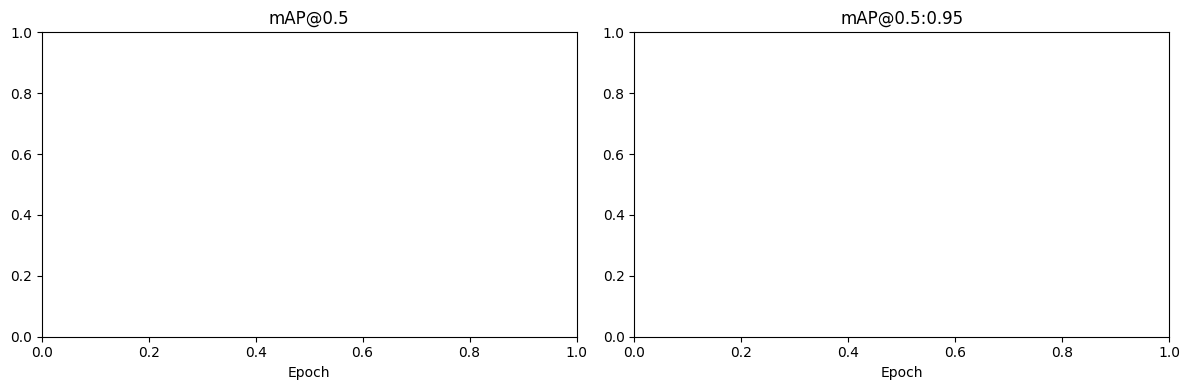

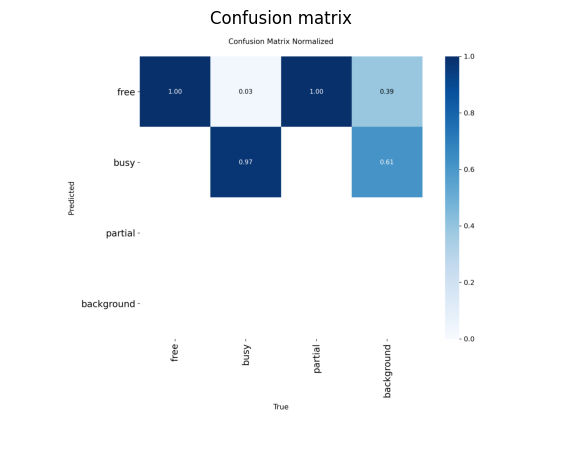

In [14]:
results_csv = RUNS_DIR / RUN_NAME / "results.csv"
if results_csv.exists():
    df_res = pd.read_csv(results_csv)
    df_res.columns = df_res.columns.str.strip()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (col, title) in zip(axes, [("metrics/mAP50", "mAP@0.5"), ("metrics/mAP50-95", "mAP@0.5:0.95")]):
        if col in df_res.columns:
            ax.plot(df_res["epoch"], df_res[col], linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "training_curves.png", dpi=120)
    plt.show()

cm_path = RUNS_DIR / RUN_NAME / "confusion_matrix_normalized.png"
if cm_path.exists():
    cm = cv2.cvtColor(cv2.imread(str(cm_path)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.axis("off")
    plt.title("Confusion matrix")
    plt.show()

## Step 10 — Inference on test images

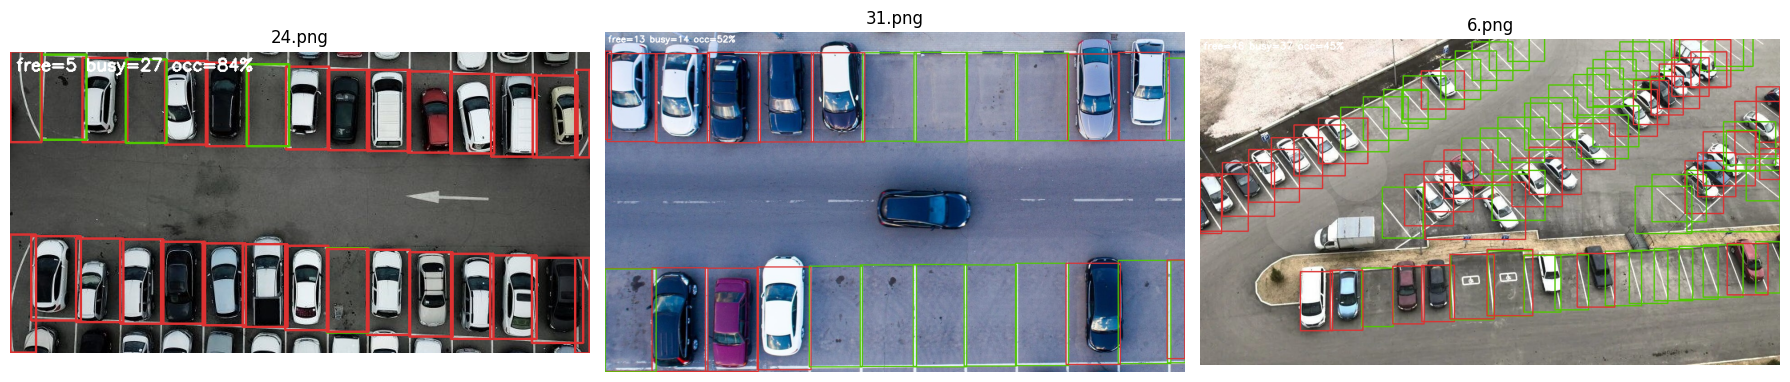

In [15]:
def run_inference_grid(model, image_paths, conf=0.25, iou=0.5, max_show=6):
    n = min(len(image_paths), max_show)
    cols = 3
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, img_path in zip(axes, image_paths[:n]):
        result = model.predict(str(img_path), conf=conf, iou=iou, verbose=False)[0]
        img = result.orig_img.copy()
        counts = {c: 0 for c in CLASS_NAMES}
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            label = CLASS_NAMES[int(box.cls[0])]
            cv2.rectangle(img, (x1, y1), (x2, y2), CLASS_COLORS[label], 2)
            counts[label] += 1
        total = sum(counts.values())
        occ = 100 * (counts["busy"] + counts["partial"]) / total if total else 0
        cv2.putText(img, f"free={counts['free']} busy={counts['busy']} occ={occ:.0f}%",
                    (8, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(Path(img_path).name)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "inference_results.png", dpi=120, bbox_inches="tight")
    plt.show()


test_imgs = sorted((YOLO_DATASET / "images" / "test").glob("*"))
run_inference_grid(best_model, test_imgs)

## Step 11 — Parking occupancy report

In [16]:
def analyze_lot(model, image_path, conf=0.25, iou=0.5):
    result = model.predict(str(image_path), conf=conf, iou=iou, verbose=False)[0]
    counts = {c: 0 for c in CLASS_NAMES}
    for box in result.boxes:
        counts[CLASS_NAMES[int(box.cls[0])]] += 1
    total = sum(counts.values())
    occupied = counts["busy"] + counts["partial"]
    return {
        "image": Path(image_path).name,
        **counts,
        "total": total,
        "occupancy_pct": 100 * occupied / total if total else 0.0,
    }


records = [analyze_lot(best_model, p) for p in tqdm(test_imgs, desc="Occupancy")]
df_occ = pd.DataFrame(records)
display(df_occ)
print(f"Mean occupancy: {df_occ['occupancy_pct'].mean():.1f}%")

Occupancy: 100%|██████████| 3/3 [00:00<00:00,  4.66it/s]


,image,free,busy,partial,total,occupancy_pct
0,24.png,5,27,0,32,84.375000
1,31.png,13,14,0,27,51.851852
2,6.png,46,37,0,83,44.578313


Mean occupancy: 60.3%


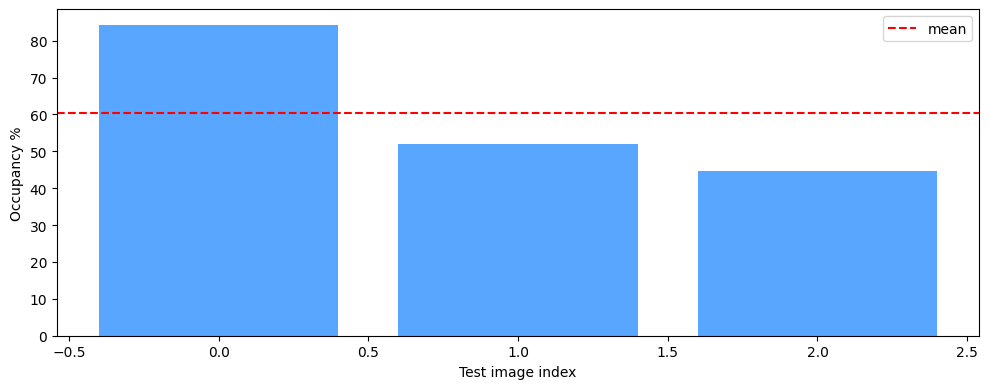

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(df_occ)), df_occ["occupancy_pct"], color="#58a6ff")
ax.axhline(df_occ["occupancy_pct"].mean(), color="red", linestyle="--", label="mean")
ax.set_xlabel("Test image index")
ax.set_ylabel("Occupancy %")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "occupancy_analysis.png", dpi=120)
plt.show()

## Step 12 — Export & summary

In [18]:
onnx_path = best_model.export(format="onnx", dynamic=True, simplify=True)
print(f"ONNX export: {onnx_path}")

print("=" * 50)
print("SMART PARKING — SUMMARY")
print("=" * 50)
print(f"Images converted : {converted}")
print(f"Classes          : {CLASS_NAMES}")
print(f"Model            : {MODEL_SIZE}")
print(f"Val  mAP50       : {val_metrics.box.map50:.4f}")
print(f"Test mAP50       : {test_metrics.box.map50:.4f}")
print(f"Best weights     : {BEST_WEIGHTS}")
print("=" * 50)

Ultralytics 8.4.52  Python-3.13.9 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-12500)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'C:\Users\nsti-\Desktop\Smart parking\smart_parking_yolo\runs\parking_yolov8m\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------